The goal of this project is to predict housing prices based on various features such as location, income level, and house characteristics. Accurate price prediction can help buyers, sellers, and investors make better decisions.

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)



The dataset contains information about housing in California. It includes variables such as income, number of rooms, population, and location.
The target variable is `median_house_value`, which represents the median house price in a given district.

In [33]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


In [2]:
df.shape

(20640, 10)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [35]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Exploration shows that the dataset contains 20,640 observations and multiple numerical and categorical features.
The `total_bedrooms` column contains missing values, which will need to be handled during preprocessing.
The variables have different scales, indicating the need for feature scaling before model training.

In [36]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Some categories appear more frequently than others, which indicates an imbalance in location distribution. Since this is a categorical variable, it will be converted into numerical form using One-Hot Encoding.

In [4]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [5]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Sayısal sütunlar:")
print(num_cols)

print("\nKategorik sütunlar:")
print(cat_cols)

Sayısal sütunlar:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

Kategorik sütunlar:
Index(['ocean_proximity'], dtype='object')


In [6]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

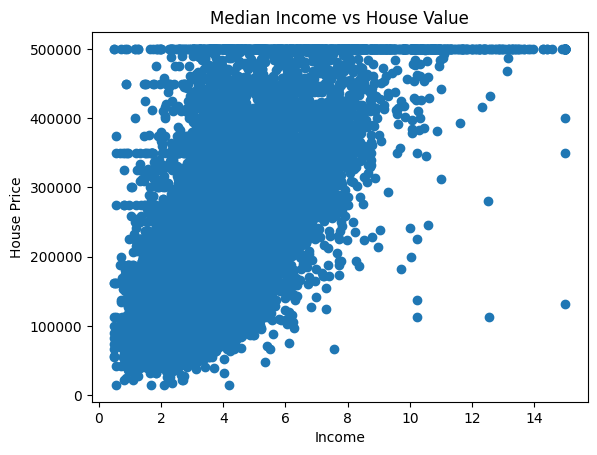

In [39]:
import matplotlib.pyplot as plt

plt.scatter(df["median_income"], df["median_house_value"])
plt.xlabel("Income")
plt.ylabel("House Price")
plt.title("Median Income vs House Value")
plt.show()

A strong positive relationship is observed between `median_income` and `median_house_value`.
This suggests that income level is one of the most important factors affecting house prices. Higher income areas tend to have higher housing prices.

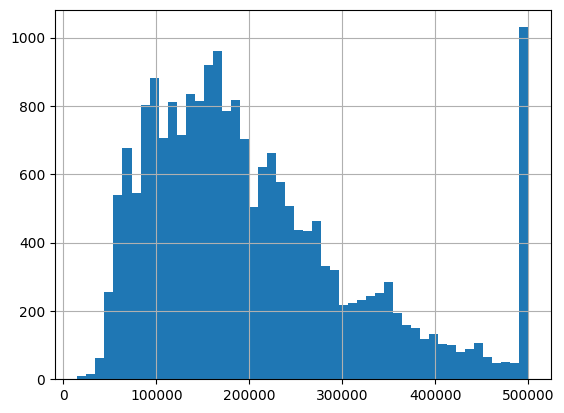

In [8]:
df["median_house_value"].hist(bins=50)
plt.show()

The distribution of the target variable is right-skewed.
This indicates that most houses fall within a mid-price range, while fewer houses have very high prices. Additionally, a noticeable cap is observed around 500,000, suggesting that the dataset has an upper limit for house prices.
This limitation may affect model performance for high-value predictions.

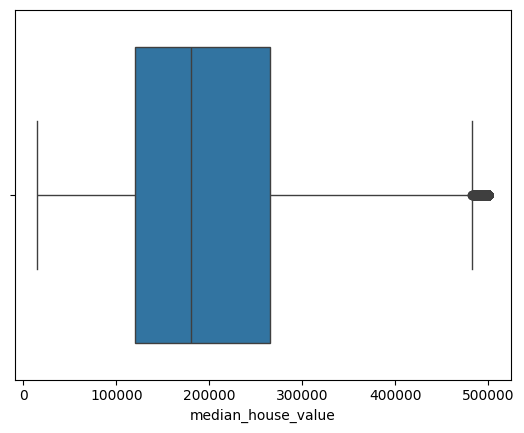

In [9]:
import seaborn as sns


sns.boxplot(x=df["median_house_value"])
plt.show()

In [44]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

## Feature Engineering
New features were created to better represent housing characteristics. These include ratios such as rooms per household and bedrooms per room. These features help improve model performance.

In [45]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

Correlation analysis shows that `median_income` has the highest positive correlation with house prices. Additionally, engineered features such as `bedrooms_per_room` show a negative correlation, indicating that houses with a higher proportion of bedrooms may have lower quality.

In [46]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)


Eğitim seti boyutu: (16512, 12)
Test seti boyutu: (4128, 12)


In [48]:
numeric_features_normal = [
    'longitude',
    'latitude',
    'housing_median_age',
    'median_income',
    'rooms_per_household',
    'population_per_household',
    'bedrooms_per_room'
]

numeric_features_skewed = [
    'total_rooms',
    'total_bedrooms',
    'population',
    'households'
]

categorical_features = ['ocean_proximity']

In [49]:
print("\nNormal Sayısal Özellikler:", numeric_features_normal)
print("Çarpık Sayısal Özellikler:", numeric_features_skewed)
print("Kategorik Özellikler:", categorical_features)



Normal Sayısal Özellikler: ['longitude', 'latitude', 'housing_median_age', 'median_income', 'rooms_per_household', 'population_per_household', 'bedrooms_per_room']
Çarpık Sayısal Özellikler: ['total_rooms', 'total_bedrooms', 'population', 'households']
Kategorik Özellikler: ['ocean_proximity']


In [50]:
numeric_transformer_normal = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [51]:
skewed_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('logtransform', FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ('scaler', StandardScaler())
    ])

In [52]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_normal', numeric_transformer_normal, numeric_features_normal),
        ('num_skewed', skewed_transformer, numeric_features_skewed),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("Preprocessing pipeline oluşturuldu.")

Preprocessing pipeline oluşturuldu.


## Data Preprocessing Pipeline

A preprocessing pipeline was created to handle all data transformations.

This includes:
- Handling missing values
- Scaling numerical features
- Encoding categorical variables

Feature engineering was also integrated into the pipeline, making the system fully automated.

In [53]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


In [54]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_normal', ...), ('num_skewed', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

In [55]:
predictions = model.predict(X_test)

In [56]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 67117.48557995073
R2: 0.656232752875205


In [57]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

print("Modeller test ediliyor...")


Modeller test ediliyor...


In [58]:
for model_name, model in models.items():
    
    full_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])
    
    scores = cross_val_score(
        full_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    rmse_scores = -scores
    results[model_name] = rmse_scores.mean()
    
    print(f"{model_name}: RMSE = {rmse_scores.mean():.2f}")

Linear Regression: RMSE = 66282.43
Random Forest: RMSE = 50250.11
Gradient Boosting: RMSE = 52642.99


## Model Comparison

Different models were tested including Linear Regression, Random Forest, and Gradient Boosting.

Random Forest achieved the best performance with the lowest RMSE, indicating better predictive ability. So I chose it.



In [59]:
tune_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

print("Hyperparameter tuning başlıyor...")

grid_search = GridSearchCV(
    tune_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Optimizasyon tamamlandı!")
print("En iyi parametreler:", grid_search.best_params_)
print("En iyi CV RMSE:", -grid_search.best_score_)

final_pipeline = grid_search.best_estimator_

Hyperparameter tuning başlıyor...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Optimizasyon tamamlandı!
En iyi parametreler: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
En iyi CV RMSE: 50113.06185649619


## Hyperparameter Tuning

GridSearchCV was used to optimize the Random Forest model. Different parameters were tested using cross-validation, and the best parameters were selected based on RMSE. This improved performance of the model.

In [65]:
y_pred = final_pipeline.predict(X_test)
y_pred = final_pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("FINAL MODEL SONUÇLARI")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")

FINAL MODEL SONUÇLARI
RMSE: 67117.49
R2: 0.8134


## Final Model Evaluation

This means the model explains about 81% of the variance in housing prices.
The RMSE indicates an average prediction error of approximately $67.117.

In [61]:
def add_features(X):
    X = X.copy()
    
    X["rooms_per_household"] = X["total_rooms"] / X["households"]
    X["bedrooms_per_room"] = X["total_bedrooms"] / X["total_rooms"]
    X["population_per_household"] = X["population"] / X["households"]
    
    return X

In [62]:
feature_engineering = FunctionTransformer(add_features)

In [63]:
full_pipeline = Pipeline([
    ("feature_engineering", feature_engineering), 
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        min_samples_leaf=2
    ))
])

In [64]:
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

## Conclusion

In this project, an end-to-end machine learning pipeline was developed to predict housing prices.

The process included data exploration, feature engineering, preprocessing, model comparison, and hyperparameter tuning.

Random Forest was selected as the final model due to its superior performance.

The model provides reliable predictions and demonstrates the effectiveness of machine learning in real estate analysis.